# 1. Load packages and cleaned dataset

In [1]:
# Air Quality Risk Prediction
# Notebook 03: Final Inferential Tests

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from scipy import stats
from scipy.stats import chi2_contingency

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Final study-specific threshold used across the project
FINAL_AQI_THRESHOLD = 35

print("Packages loaded successfully.")
print(f"Final AQI threshold: overall_aqi > {FINAL_AQI_THRESHOLD}")

Packages loaded successfully.
Final AQI threshold: overall_aqi > 35


In [2]:
from google.colab import files

uploaded = files.upload()

Saving aq_daily_merged_clean.csv to aq_daily_merged_clean.csv


In [3]:
# Load final cleaned dataset from Notebook 01

df = pd.read_csv("aq_daily_merged_clean.csv")
df["date"] = pd.to_datetime(df["date"])

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")

df.head()

Dataset loaded successfully.
Rows: 731
Columns: 41
Date range: 2024-01-01 to 2025-12-31


,date,site_id,local_site_name,county,state,site_latitude,site_longitude,station,station_name,daily_max_8hr_ozone,daily_aqi_ozone,daily_obs_count_ozone,percent_complete_ozone,ozone_poc,daily_mean_pm10,daily_aqi_pm10,daily_obs_count_pm10,percent_complete_pm10,pm10_poc,daily_mean_pm25,daily_aqi_pm25,daily_obs_count_pm25,percent_complete_pm25,pm25_poc,daily_max_1hr_no2,daily_aqi_no2,daily_obs_count_no2,percent_complete_no2,no2_poc,awnd,prcp,tmax,tmin,overall_aqi,poor_air_quality,year,month,day_of_week,is_weekend,season,dominant_pollutant
0,2024-01-01,150030010,Kapolei,Honolulu,Hawaii,21.323745,-158.088613,USW00022521,"HONOLULU INTERNATIONAL AIRPORT, HI US",0.033,31.0,17.0,100.0,1.0,13.0,12.0,1.0,100.0,3.0,5.400000,32.0,2.0,100.0,"1,21",11.8,10.0,22.0,92.0,1.0,4.7,0.0,26.7,18.3,32.0,0,2024,1,Monday,0,Winter,PM2.5
1,2024-01-02,150030010,Kapolei,Honolulu,Hawaii,21.323745,-158.088613,USW00022521,"HONOLULU INTERNATIONAL AIRPORT, HI US",0.035,32.0,17.0,100.0,1.0,20.0,19.0,1.0,100.0,3.0,4.950000,30.0,2.0,100.0,"1,21",16.1,15.0,24.0,100.0,1.0,4.6,0.0,27.8,22.2,32.0,0,2024,1,Tuesday,0,Winter,Ozone
2,2024-01-03,150030010,Kapolei,Honolulu,Hawaii,21.323745,-158.088613,USW00022521,"HONOLULU INTERNATIONAL AIRPORT, HI US",0.035,32.0,17.0,100.0,1.0,25.0,23.0,1.0,100.0,3.0,5.666667,37.0,3.0,100.0,"1,2,21",13.0,12.0,24.0,100.0,1.0,3.5,0.0,28.9,19.4,37.0,1,2024,1,Wednesday,0,Winter,PM2.5
3,2024-01-04,150030010,Kapolei,Honolulu,Hawaii,21.323745,-158.088613,USW00022521,"HONOLULU INTERNATIONAL AIRPORT, HI US",0.033,31.0,17.0,100.0,1.0,21.0,19.0,1.0,100.0,3.0,5.833333,37.0,3.0,100.0,"1,2,21",17.4,16.0,24.0,100.0,1.0,2.4,0.0,26.7,19.4,37.0,1,2024,1,Thursday,0,Winter,PM2.5
4,2024-01-05,150030010,Kapolei,Honolulu,Hawaii,21.323745,-158.088613,USW00022521,"HONOLULU INTERNATIONAL AIRPORT, HI US",0.031,29.0,17.0,100.0,1.0,23.0,21.0,1.0,100.0,3.0,7.100000,42.0,2.0,100.0,"1,21",17.9,16.0,24.0,100.0,1.0,2.1,0.0,27.2,19.4,42.0,1,2024,1,Friday,0,Winter,PM2.5


# 2. Confirm target and season variables

In [4]:
# Confirm key variables needed for inferential testing

required_cols = [
    "date",
    "overall_aqi",
    "poor_air_quality",
    "season",
    "month",
    "day_of_week",
    "is_weekend"
]

missing_required_cols = [col for col in required_cols if col not in df.columns]

if missing_required_cols:
    print("Missing required columns:")
    print(missing_required_cols)
else:
    print("All required columns are present.")

print("\nTarget distribution:")
print(df["poor_air_quality"].value_counts().sort_index())

print("\nTarget distribution (%):")
print((df["poor_air_quality"].value_counts(normalize=True).sort_index() * 100).round(2))

print("\nSeason counts:")
print(df["season"].value_counts())

print("\nMissing values in key variables:")
print(df[required_cols].isna().sum())

All required columns are present.

Target distribution:
poor_air_quality
0    581
1    150
Name: count, dtype: int64

Target distribution (%):
poor_air_quality
0    79.48
1    20.52
Name: proportion, dtype: float64

Season counts:
season
Spring    184
Summer    184
Fall      182
Winter    181
Name: count, dtype: int64

Missing values in key variables:
date                0
overall_aqi         0
poor_air_quality    0
season              0
month               0
day_of_week         0
is_weekend          0
dtype: int64


In [5]:
# Confirm that poor_air_quality still matches the final study threshold

df["poor_air_quality_check"] = (df["overall_aqi"] > FINAL_AQI_THRESHOLD).astype(int)

mismatch_count = (df["poor_air_quality"] != df["poor_air_quality_check"]).sum()

print(f"Target mismatch count: {mismatch_count}")

print("\nDistribution from file:")
print(df["poor_air_quality"].value_counts().sort_index())

print("\nDistribution from threshold check:")
print(df["poor_air_quality_check"].value_counts().sort_index())

df = df.drop(columns=["poor_air_quality_check"])

Target mismatch count: 0

Distribution from file:
poor_air_quality
0    581
1    150
Name: count, dtype: int64

Distribution from threshold check:
poor_air_quality_check
0    581
1    150
Name: count, dtype: int64


# 3. Run assumption checks for seasonal `overall_aqi` comparison



In [6]:
# Seasonal summary for overall_aqi

season_order = ["Winter", "Spring", "Summer", "Fall"]

seasonal_aqi_summary = (
    df
    .groupby("season")
    .agg(
        days=("date", "count"),
        mean_overall_aqi=("overall_aqi", "mean"),
        median_overall_aqi=("overall_aqi", "median"),
        std_overall_aqi=("overall_aqi", "std"),
        min_overall_aqi=("overall_aqi", "min"),
        max_overall_aqi=("overall_aqi", "max"),
        poor_air_quality_days=("poor_air_quality", "sum")
    )
    .reindex(season_order)
    .round(3)
    .reset_index()
)

seasonal_aqi_summary

,season,days,mean_overall_aqi,median_overall_aqi,std_overall_aqi,min_overall_aqi,max_overall_aqi,poor_air_quality_days
0,Winter,181,33.188,33.0,7.887,14.0,55.0,69
1,Spring,184,32.636,32.0,6.308,19.0,56.0,48
2,Summer,184,24.935,23.0,6.995,12.0,52.0,13
3,Fall,182,26.890,26.0,6.656,13.0,49.0,20


In [7]:
# Save seasonal AQI summary

Path("outputs/tables").mkdir(parents=True, exist_ok=True)

seasonal_aqi_summary.to_csv(
    "outputs/tables/final_seasonal_aqi_summary.csv",
    index=False
)

print("Saved: outputs/tables/final_seasonal_aqi_summary.csv")

Saved: outputs/tables/final_seasonal_aqi_summary.csv


In [8]:
# Shapiro-Wilk normality test for overall_aqi by season

normality_results = []

for season in season_order:
    values = df.loc[df["season"] == season, "overall_aqi"].dropna()

    shapiro_stat, shapiro_p = stats.shapiro(values)

    normality_results.append({
        "season": season,
        "n": len(values),
        "shapiro_statistic": shapiro_stat,
        "p_value": shapiro_p,
        "normality_decision_alpha_0_05": "Approximately normal" if shapiro_p >= 0.05 else "Not normal"
    })

normality_results_df = pd.DataFrame(normality_results)

normality_results_df.round(4)

,season,n,shapiro_statistic,p_value,normality_decision_alpha_0_05
0,Winter,181,0.9892,0.1855,Approximately normal
1,Spring,184,0.9431,0.0000,Not normal
2,Summer,184,0.9204,0.0000,Not normal
3,Fall,182,0.9721,0.0010,Not normal


In [9]:
# Levene's test for equality of variances across seasons

season_groups = [
    df.loc[df["season"] == season, "overall_aqi"].dropna()
    for season in season_order
]

levene_stat, levene_p = stats.levene(*season_groups)

levene_results = pd.DataFrame([{
    "test": "Levene's test",
    "statistic": levene_stat,
    "p_value": levene_p,
    "decision_alpha_0_05": "Equal variances assumed" if levene_p >= 0.05 else "Equal variances not assumed"
}])

levene_results.round(4)

,test,statistic,p_value,decision_alpha_0_05
0,Levene's test,3.0169,0.0293,Equal variances not assumed


# 4. Run ANOVA or Kruskal-Wallis for `overall_aqi` by season

In [10]:
# Seasonal differences in overall_aqi: ANOVA and Kruskal-Wallis

anova_stat, anova_p = stats.f_oneway(*season_groups)

kruskal_stat, kruskal_p = stats.kruskal(*season_groups)

seasonal_test_results = pd.DataFrame([
    {
        "research_question": "RQ3",
        "outcome": "overall_aqi",
        "grouping_variable": "season",
        "test": "One-way ANOVA",
        "statistic": anova_stat,
        "p_value": anova_p,
        "decision_alpha_0_05": "Reject H0" if anova_p < 0.05 else "Fail to reject H0"
    },
    {
        "research_question": "RQ3",
        "outcome": "overall_aqi",
        "grouping_variable": "season",
        "test": "Kruskal-Wallis",
        "statistic": kruskal_stat,
        "p_value": kruskal_p,
        "decision_alpha_0_05": "Reject H0" if kruskal_p < 0.05 else "Fail to reject H0"
    }
])

seasonal_test_results.round(4)

,research_question,outcome,grouping_variable,test,statistic,p_value,decision_alpha_0_05
0,RQ3,overall_aqi,season,One-way ANOVA,63.8365,0.0,Reject H0
1,RQ3,overall_aqi,season,Kruskal-Wallis,171.0418,0.0,Reject H0


In [11]:
# Save assumption and seasonal test results

normality_results_df.to_csv(
    "outputs/tables/final_shapiro_normality_by_season.csv",
    index=False
)

levene_results.to_csv(
    "outputs/tables/final_levene_variance_test.csv",
    index=False
)

seasonal_test_results.to_csv(
    "outputs/tables/final_seasonal_overall_aqi_tests.csv",
    index=False
)

print("Saved:")
print("outputs/tables/final_shapiro_normality_by_season.csv")
print("outputs/tables/final_levene_variance_test.csv")
print("outputs/tables/final_seasonal_overall_aqi_tests.csv")

Saved:
outputs/tables/final_shapiro_normality_by_season.csv
outputs/tables/final_levene_variance_test.csv
outputs/tables/final_seasonal_overall_aqi_tests.csv


#5. Post hoc pairwise seasonal comparison

In [12]:
# Pairwise seasonal comparisons for overall_aqi using Mann-Whitney U tests
# Bonferroni correction is applied for multiple comparisons.

from itertools import combinations

pairwise_results = []

season_pairs = list(combinations(season_order, 2))
num_comparisons = len(season_pairs)

for season_a, season_b in season_pairs:
    values_a = df.loc[df["season"] == season_a, "overall_aqi"].dropna()
    values_b = df.loc[df["season"] == season_b, "overall_aqi"].dropna()

    u_stat, p_value = stats.mannwhitneyu(
        values_a,
        values_b,
        alternative="two-sided"
    )

    p_bonferroni = min(p_value * num_comparisons, 1.0)

    pairwise_results.append({
        "research_question": "RQ3",
        "outcome": "overall_aqi",
        "comparison": f"{season_a} vs {season_b}",
        "test": "Mann-Whitney U",
        "u_statistic": u_stat,
        "raw_p_value": p_value,
        "bonferroni_adjusted_p_value": p_bonferroni,
        "decision_alpha_0_05": "Reject H0" if p_bonferroni < 0.05 else "Fail to reject H0"
    })

pairwise_season_results = pd.DataFrame(pairwise_results)

pairwise_season_results.round(4)

,research_question,outcome,comparison,test,u_statistic,raw_p_value,bonferroni_adjusted_p_value,decision_alpha_0_05
0,RQ3,overall_aqi,Winter vs Spring,Mann-Whitney U,17780.5,0.2625,1.0000,Fail to reject H0
1,RQ3,overall_aqi,Winter vs Summer,Mann-Whitney U,26562.5,0.0000,0.0000,Reject H0
2,RQ3,overall_aqi,Winter vs Fall,Mann-Whitney U,24128.5,0.0000,0.0000,Reject H0
3,RQ3,overall_aqi,Spring vs Summer,Mann-Whitney U,27778.5,0.0000,0.0000,Reject H0
4,RQ3,overall_aqi,Spring vs Fall,Mann-Whitney U,24749.5,0.0000,0.0000,Reject H0
5,RQ3,overall_aqi,Summer vs Fall,Mann-Whitney U,13540.0,0.0015,0.0091,Reject H0


In [13]:
# Save pairwise seasonal comparison results

pairwise_season_results.to_csv(
    "outputs/tables/final_pairwise_seasonal_overall_aqi_tests.csv",
    index=False
)

print("Saved: outputs/tables/final_pairwise_seasonal_overall_aqi_tests.csv")

Saved: outputs/tables/final_pairwise_seasonal_overall_aqi_tests.csv


/tmp/ipykernel_15025/3230901483.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_by_season, labels=season_order)


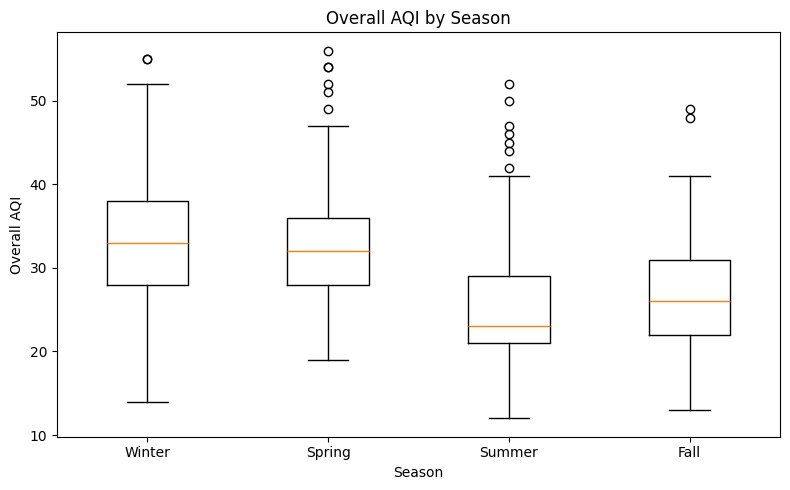

Saved: outputs/figures/final_overall_aqi_by_season_boxplot.png


In [14]:
# Save final seasonal AQI boxplot

Path("outputs/figures").mkdir(parents=True, exist_ok=True)

data_by_season = [
    df.loc[df["season"] == season, "overall_aqi"].dropna()
    for season in season_order
]

plt.figure(figsize=(8, 5))
plt.boxplot(data_by_season, labels=season_order)
plt.title("Overall AQI by Season")
plt.xlabel("Season")
plt.ylabel("Overall AQI")
plt.tight_layout()

plt.savefig(
    "outputs/figures/final_overall_aqi_by_season_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: outputs/figures/final_overall_aqi_by_season_boxplot.png")

# 6. Second RQ3 test: whether the frequency of poor air quality days differs by season

In [15]:
# Contingency table for poor_air_quality by season

season_target_table = pd.crosstab(
    df["season"],
    df["poor_air_quality"]
).reindex(season_order)

season_target_table.columns = ["not_poor_air_quality", "poor_air_quality"]

season_target_table

,not_poor_air_quality,poor_air_quality
season,,
Winter,112,69
Spring,136,48
Summer,171,13
Fall,162,20


In [16]:
# Poor air quality percentages by season

season_target_percent = season_target_table.copy()

season_target_percent["total_days"] = season_target_percent.sum(axis=1)
season_target_percent["poor_air_quality_percent"] = (
    season_target_percent["poor_air_quality"] / season_target_percent["total_days"] * 100
).round(2)

season_target_percent

,not_poor_air_quality,poor_air_quality,total_days,poor_air_quality_percent
season,,,,
Winter,112,69,181,38.12
Spring,136,48,184,26.09
Summer,171,13,184,7.07
Fall,162,20,182,10.99


# 7. Run chi-square test for `poor_air_quality` by season

In [17]:
# Chi-square test of independence for poor_air_quality by season

chi2_stat, chi2_p, chi2_dof, expected = chi2_contingency(season_target_table)

chi_square_results = pd.DataFrame([{
    "research_question": "RQ3",
    "outcome": "poor_air_quality",
    "grouping_variable": "season",
    "test": "Chi-square test of independence",
    "chi_square_statistic": chi2_stat,
    "degrees_of_freedom": chi2_dof,
    "p_value": chi2_p,
    "decision_alpha_0_05": "Reject H0" if chi2_p < 0.05 else "Fail to reject H0"
}])

chi_square_results.round(4)

,research_question,outcome,grouping_variable,test,chi_square_statistic,degrees_of_freedom,p_value,decision_alpha_0_05
0,RQ3,poor_air_quality,season,Chi-square test of independence,68.4407,3,0.0,Reject H0


In [18]:
# Expected frequencies from chi-square test

expected_frequencies = pd.DataFrame(
    expected,
    index=season_target_table.index,
    columns=season_target_table.columns
)

expected_frequencies.round(2)

,not_poor_air_quality,poor_air_quality
season,,
Winter,143.86,37.14
Spring,146.24,37.76
Summer,146.24,37.76
Fall,144.65,37.35


In [19]:
# Save chi-square outputs

season_target_table.to_csv(
    "outputs/tables/final_poor_air_quality_by_season_counts.csv"
)

season_target_percent.to_csv(
    "outputs/tables/final_poor_air_quality_by_season_percent.csv"
)

chi_square_results.to_csv(
    "outputs/tables/final_chi_square_poor_air_quality_by_season.csv",
    index=False
)

expected_frequencies.to_csv(
    "outputs/tables/final_chi_square_expected_frequencies.csv"
)

print("Saved:")
print("outputs/tables/final_poor_air_quality_by_season_counts.csv")
print("outputs/tables/final_poor_air_quality_by_season_percent.csv")
print("outputs/tables/final_chi_square_poor_air_quality_by_season.csv")
print("outputs/tables/final_chi_square_expected_frequencies.csv")

Saved:
outputs/tables/final_poor_air_quality_by_season_counts.csv
outputs/tables/final_poor_air_quality_by_season_percent.csv
outputs/tables/final_chi_square_poor_air_quality_by_season.csv
outputs/tables/final_chi_square_expected_frequencies.csv


# 8. weekday vs. weekend test

In [20]:
# Weekday vs. weekend summary for overall_aqi and poor_air_quality

weekend_summary = (
    df
    .groupby("is_weekend")
    .agg(
        days=("date", "count"),
        mean_overall_aqi=("overall_aqi", "mean"),
        median_overall_aqi=("overall_aqi", "median"),
        std_overall_aqi=("overall_aqi", "std"),
        min_overall_aqi=("overall_aqi", "min"),
        max_overall_aqi=("overall_aqi", "max"),
        poor_air_quality_days=("poor_air_quality", "sum")
    )
    .round(3)
    .reset_index()
)

weekend_summary["day_type"] = weekend_summary["is_weekend"].map({
    0: "Weekday",
    1: "Weekend"
})

weekend_summary = weekend_summary[
    [
        "day_type",
        "is_weekend",
        "days",
        "mean_overall_aqi",
        "median_overall_aqi",
        "std_overall_aqi",
        "min_overall_aqi",
        "max_overall_aqi",
        "poor_air_quality_days"
    ]
]

weekend_summary

,day_type,is_weekend,days,mean_overall_aqi,median_overall_aqi,std_overall_aqi,min_overall_aqi,max_overall_aqi,poor_air_quality_days
0,Weekday,0,523,29.272,29.0,8.047,12.0,56.0,106
1,Weekend,1,208,29.736,29.0,7.275,13.0,52.0,44


In [21]:
# Assumption checks for weekday vs. weekend overall_aqi comparison

weekday_values = df.loc[df["is_weekend"] == 0, "overall_aqi"].dropna()
weekend_values = df.loc[df["is_weekend"] == 1, "overall_aqi"].dropna()

# Shapiro-Wilk normality tests
weekday_shapiro_stat, weekday_shapiro_p = stats.shapiro(weekday_values)
weekend_shapiro_stat, weekend_shapiro_p = stats.shapiro(weekend_values)

# Levene's test for equal variances
weekend_levene_stat, weekend_levene_p = stats.levene(weekday_values, weekend_values)

weekend_assumption_results = pd.DataFrame([
    {
        "group": "Weekday",
        "n": len(weekday_values),
        "test": "Shapiro-Wilk",
        "statistic": weekday_shapiro_stat,
        "p_value": weekday_shapiro_p,
        "decision_alpha_0_05": "Approximately normal" if weekday_shapiro_p >= 0.05 else "Not normal"
    },
    {
        "group": "Weekend",
        "n": len(weekend_values),
        "test": "Shapiro-Wilk",
        "statistic": weekend_shapiro_stat,
        "p_value": weekend_shapiro_p,
        "decision_alpha_0_05": "Approximately normal" if weekend_shapiro_p >= 0.05 else "Not normal"
    },
    {
        "group": "Weekday vs Weekend",
        "n": len(weekday_values) + len(weekend_values),
        "test": "Levene's test",
        "statistic": weekend_levene_stat,
        "p_value": weekend_levene_p,
        "decision_alpha_0_05": "Equal variances assumed" if weekend_levene_p >= 0.05 else "Equal variances not assumed"
    }
])

weekend_assumption_results.round(4)

,group,n,test,statistic,p_value,decision_alpha_0_05
0,Weekday,523,Shapiro-Wilk,0.9764,0.0000,Not normal
1,Weekend,208,Shapiro-Wilk,0.9803,0.0051,Not normal
2,Weekday vs Weekend,731,Levene's test,2.0784,0.1498,Equal variances assumed


In [22]:
# Weekday vs. weekend comparison for overall_aqi

# Welch's t-test does not assume equal variances
ttest_stat, ttest_p = stats.ttest_ind(
    weekday_values,
    weekend_values,
    equal_var=False
)

# Mann-Whitney U test as nonparametric alternative
mw_stat, mw_p = stats.mannwhitneyu(
    weekday_values,
    weekend_values,
    alternative="two-sided"
)

weekend_aqi_test_results = pd.DataFrame([
    {
        "research_question": "RQ3",
        "outcome": "overall_aqi",
        "grouping_variable": "is_weekend",
        "comparison": "Weekday vs Weekend",
        "test": "Welch's t-test",
        "statistic": ttest_stat,
        "p_value": ttest_p,
        "decision_alpha_0_05": "Reject H0" if ttest_p < 0.05 else "Fail to reject H0"
    },
    {
        "research_question": "RQ3",
        "outcome": "overall_aqi",
        "grouping_variable": "is_weekend",
        "comparison": "Weekday vs Weekend",
        "test": "Mann-Whitney U",
        "statistic": mw_stat,
        "p_value": mw_p,
        "decision_alpha_0_05": "Reject H0" if mw_p < 0.05 else "Fail to reject H0"
    }
])

weekend_aqi_test_results.round(4)

,research_question,outcome,grouping_variable,comparison,test,statistic,p_value,decision_alpha_0_05
0,RQ3,overall_aqi,is_weekend,Weekday vs Weekend,Welch's t-test,-0.7545,0.4510,Fail to reject H0
1,RQ3,overall_aqi,is_weekend,Weekday vs Weekend,Mann-Whitney U,51982.5000,0.3493,Fail to reject H0


In [23]:
# Chi-square test for poor_air_quality by weekday/weekend

weekend_target_table = pd.crosstab(
    df["is_weekend"],
    df["poor_air_quality"]
)

weekend_target_table.index = ["Weekday", "Weekend"]
weekend_target_table.columns = ["not_poor_air_quality", "poor_air_quality"]

weekend_target_table

,not_poor_air_quality,poor_air_quality
Weekday,417,106
Weekend,164,44


In [24]:
# Percent of poor air quality days by weekday/weekend

weekend_target_percent = weekend_target_table.copy()

weekend_target_percent["total_days"] = weekend_target_percent.sum(axis=1)
weekend_target_percent["poor_air_quality_percent"] = (
    weekend_target_percent["poor_air_quality"] / weekend_target_percent["total_days"] * 100
).round(2)

weekend_target_percent

,not_poor_air_quality,poor_air_quality,total_days,poor_air_quality_percent
Weekday,417,106,523,20.27
Weekend,164,44,208,21.15


In [25]:
# Chi-square test of independence for poor_air_quality by weekday/weekend

weekend_chi2_stat, weekend_chi2_p, weekend_chi2_dof, weekend_expected = chi2_contingency(
    weekend_target_table
)

weekend_chi_square_results = pd.DataFrame([{
    "research_question": "RQ3",
    "outcome": "poor_air_quality",
    "grouping_variable": "is_weekend",
    "test": "Chi-square test of independence",
    "chi_square_statistic": weekend_chi2_stat,
    "degrees_of_freedom": weekend_chi2_dof,
    "p_value": weekend_chi2_p,
    "decision_alpha_0_05": "Reject H0" if weekend_chi2_p < 0.05 else "Fail to reject H0"
}])

weekend_chi_square_results.round(4)

,research_question,outcome,grouping_variable,test,chi_square_statistic,degrees_of_freedom,p_value,decision_alpha_0_05
0,RQ3,poor_air_quality,is_weekend,Chi-square test of independence,0.0276,1,0.868,Fail to reject H0


In [26]:
# Expected frequencies for weekday/weekend chi-square test

weekend_expected_frequencies = pd.DataFrame(
    weekend_expected,
    index=weekend_target_table.index,
    columns=weekend_target_table.columns
)

weekend_expected_frequencies.round(2)

,not_poor_air_quality,poor_air_quality
Weekday,415.68,107.32
Weekend,165.32,42.68


In [27]:
# Save weekday/weekend outputs

weekend_summary.to_csv(
    "outputs/tables/final_weekday_weekend_summary.csv",
    index=False
)

weekend_assumption_results.to_csv(
    "outputs/tables/final_weekday_weekend_assumption_tests.csv",
    index=False
)

weekend_aqi_test_results.to_csv(
    "outputs/tables/final_weekday_weekend_overall_aqi_tests.csv",
    index=False
)

weekend_target_table.to_csv(
    "outputs/tables/final_weekday_weekend_poor_air_quality_counts.csv"
)

weekend_target_percent.to_csv(
    "outputs/tables/final_weekday_weekend_poor_air_quality_percent.csv"
)

weekend_chi_square_results.to_csv(
    "outputs/tables/final_weekday_weekend_chi_square.csv",
    index=False
)

weekend_expected_frequencies.to_csv(
    "outputs/tables/final_weekday_weekend_expected_frequencies.csv"
)

print("Saved weekday/weekend test outputs.")

Saved weekday/weekend test outputs.


# 9. Save final inferential test results table

In [28]:
# Create one combined final inferential results table for the final report

combined_inferential_results = pd.DataFrame([
    {
        "research_question": "RQ3",
        "analysis_area": "Seasonal differences in overall AQI",
        "outcome": "overall_aqi",
        "grouping_variable": "season",
        "primary_test": "Kruskal-Wallis",
        "test_statistic": 171.0418,
        "degrees_of_freedom": 3,
        "p_value": "< .001",
        "decision_alpha_0_05": "Reject H0",
        "interpretation": "Overall AQI differed significantly across seasons."
    },
    {
        "research_question": "RQ3",
        "analysis_area": "Pairwise seasonal comparisons",
        "outcome": "overall_aqi",
        "grouping_variable": "season",
        "primary_test": "Mann-Whitney U with Bonferroni correction",
        "test_statistic": np.nan,
        "degrees_of_freedom": np.nan,
        "p_value": "Varies by pair",
        "decision_alpha_0_05": "Mostly reject H0",
        "interpretation": "Winter and spring did not differ significantly, but most other seasonal pairs differed significantly."
    },
    {
        "research_question": "RQ3",
        "analysis_area": "Seasonal differences in poor air quality frequency",
        "outcome": "poor_air_quality",
        "grouping_variable": "season",
        "primary_test": "Chi-square test of independence",
        "test_statistic": 68.4407,
        "degrees_of_freedom": 3,
        "p_value": "< .001",
        "decision_alpha_0_05": "Reject H0",
        "interpretation": "The frequency of poor air quality days differed significantly by season."
    },
    {
        "research_question": "RQ3",
        "analysis_area": "Weekday vs weekend differences in overall AQI",
        "outcome": "overall_aqi",
        "grouping_variable": "is_weekend",
        "primary_test": "Mann-Whitney U",
        "test_statistic": 51982.5,
        "degrees_of_freedom": np.nan,
        "p_value": ".349",
        "decision_alpha_0_05": "Fail to reject H0",
        "interpretation": "Overall AQI did not differ significantly between weekdays and weekends."
    },
    {
        "research_question": "RQ3",
        "analysis_area": "Weekday vs weekend differences in poor air quality frequency",
        "outcome": "poor_air_quality",
        "grouping_variable": "is_weekend",
        "primary_test": "Chi-square test of independence",
        "test_statistic": 0.0276,
        "degrees_of_freedom": 1,
        "p_value": ".868",
        "decision_alpha_0_05": "Fail to reject H0",
        "interpretation": "The frequency of poor air quality days did not differ significantly between weekdays and weekends."
    }
])

combined_inferential_results

,research_question,analysis_area,outcome,grouping_variable,primary_test,test_statistic,degrees_of_freedom,p_value,decision_alpha_0_05,interpretation
0,RQ3,Seasonal differences in overall AQI,overall_aqi,season,Kruskal-Wallis,171.0418,3.0,< .001,Reject H0,Overall AQI differed significantly across seas...
1,RQ3,Pairwise seasonal comparisons,overall_aqi,season,Mann-Whitney U with Bonferroni correction,NaN,NaN,Varies by pair,Mostly reject H0,Winter and spring did not differ significantly...
2,RQ3,Seasonal differences in poor air quality frequ...,poor_air_quality,season,Chi-square test of independence,68.4407,3.0,< .001,Reject H0,The frequency of poor air quality days differe...
3,RQ3,Weekday vs weekend differences in overall AQI,overall_aqi,is_weekend,Mann-Whitney U,51982.5000,NaN,.349,Fail to reject H0,Overall AQI did not differ significantly betwe...
4,RQ3,Weekday vs weekend differences in poor air qua...,poor_air_quality,is_weekend,Chi-square test of independence,0.0276,1.0,.868,Fail to reject H0,The frequency of poor air quality days did not...


In [29]:
# Save combined inferential results table

combined_inferential_results.to_csv(
    "outputs/tables/final_combined_inferential_results.csv",
    index=False
)

print("Saved: outputs/tables/final_combined_inferential_results.csv")

Saved: outputs/tables/final_combined_inferential_results.csv


In [30]:
# Save final RQ3 interpretation text for easy report drafting

rq3_interpretation = """
RQ3 asked whether poor air quality days varied significantly across seasons and time periods.
The results showed strong evidence of seasonal variation. The Kruskal-Wallis test showed that
overall AQI differed significantly across seasons, H = 171.04, p < .001. Post hoc Mann-Whitney U
tests with Bonferroni correction showed that winter and spring did not differ significantly from
each other, but most other seasonal pairs differed significantly.

A chi-square test of independence also showed that the frequency of poor air quality days differed
significantly by season, χ²(3) = 68.44, p < .001. Winter had the highest proportion of poor air
quality days at 38.12%, followed by spring at 26.09%, fall at 10.99%, and summer at 7.07%.

Weekday/weekend differences were not statistically significant. The Mann-Whitney U test showed no
significant difference in overall AQI between weekdays and weekends, U = 51,982.50, p = .349.
The chi-square test also showed no significant association between weekday/weekend status and poor
air quality frequency, χ²(1) = 0.03, p = .868. These findings indicate that seasonal variation was
more meaningful than weekday/weekend variation in the current dataset.
"""

with open("outputs/tables/final_rq3_interpretation.txt", "w") as file:
    file.write(rq3_interpretation.strip())

print("Saved: outputs/tables/final_rq3_interpretation.txt")

Saved: outputs/tables/final_rq3_interpretation.txt


In [31]:
# Zip and download Notebook 03 final inferential test outputs

import shutil
from google.colab import files

zip_file_name = "notebook_03_final_inferential_outputs"

shutil.make_archive(
    zip_file_name,
    "zip",
    "outputs"
)

files.download(f"{zip_file_name}.zip")

print(f"Created and downloaded: {zip_file_name}.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Created and downloaded: notebook_03_final_inferential_outputs.zip
